# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [ ]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


In [ ]:
# download data
!wget -q "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip" -O online_retail_ii.zip
!unzip -o online_retail_ii.zip
!ls *.xlsx  # confirm the filename

Archive:  online_retail_ii.zip
 extracting: online_retail_II.xlsx   
online_retail_II.xlsx


In [ ]:
# Load the dataset
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')


In [ ]:

# ── First Look ──────────────────────────────────────────────────────────────

# Print shape
print("Shape:", df.shape)

# Print dtypes
print("\nDtypes:")
print(df.dtypes)

# Print first 5 rows
print("\nFirst 5 rows:")
print(df.head())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Print basic descriptive statistics
print("\nDescribe:")
print(df.describe())

Shape: (541910, 8)

Dtypes:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

First 5 rows:
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17850.0 

---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
**answer:** 541910 rows, 8 columns
- What does one row represent?
**answer:** sold items
- Which columns will be useful for customer-level aggregation?
**answer:** Description,Quantity,
InvoiceDate, Price, Customer ID, Country
- What problems do you already see?
**answer:**
1. customer id is in float
2. lots of customer id missing
3. prices and quantity are  in negatives
4. outliers in price and quantity can cause distortion in statistical analysis

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

_Write here before moving on._

1. customer id is in float
2. lots of customer id missing
3. prices and quantity are  in negatives
4. outliers in price and quantity can cause distortion in statistical analysis


## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [ ]:
# Work on a copy — never mutate the original
df_clean = df.copy()

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# Why? Write your reasoning as a comment before the code
# 1. without a customer id we cannot attribute purchases to a customer
# 2. then we cannot segment the customer base
before =len(df_clean)
df_clean=df_clean.dropna(subset=['Customer ID'])

# How many rows are you dropping?
print(f"Dropped {before - len(df_clean)} rows with missing CustomerID")


# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Cancelled invoices start with 'C'
# Why remove them? What would happen if you kept them in Monetary calculation?
# YOUR CODE HERE
before = len(df_clean)
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print(f"Dropped {before - len(df_clean)} cancelled transactions")

# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
# YOUR CODE HERE
before = len(df_clean)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"Dropped {before - len(df_clean)} rows with negative Quantity or Price")


# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# YOUR CODE HERE
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# TotalPrice = Quantity * Price
# YOUR CODE HERE
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# Summary — print shape before and after, and rows lost at each step
print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")


Dropped 135080 rows with missing CustomerID
Dropped 8905 cancelled transactions
Dropped 40 rows with negative Quantity or Price
Original shape: (541910, 8)
Clean shape: (397885, 9)
Rows removed: 144025


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [ ]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Choose a reference date for Recency calculation
# Justify your choice in a comment — why this date?
# Use one day after the last invoice in the dataset.
# This makes Recency = 1 for the most recent customer (avoids 0-day recency).
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")


# ── Recency ──────────────────────────────────────────────────────────────────
# Days since last purchase per customer
# YOUR CODE HERE
recency_df = df_clean.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency_df.columns = ['Customer ID', 'LastPurchase']
recency_df['Recency'] = (reference_date - recency_df['LastPurchase']).dt.days

# ── Frequency ────────────────────────────────────────────────────────────────
# Number of unique invoices per customer
# YOUR CODE HERE
frequency_df = df_clean.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency_df.columns = ['Customer ID', 'Frequency']

# ── Monetary ─────────────────────────────────────────────────────────────────
# Total spend per customer
# YOUR CODE HERE
# Limitation: doesn't account for returns (already removed cancellations above).
monetary_df = df_clean.groupby('Customer ID')['TotalPrice'].sum().reset_index()
monetary_df.columns = ['Customer ID', 'Monetary']

# ── Combine into customer matrix ─────────────────────────────────────────────
# YOUR CODE HERE
# customer_df should have columns: CustomerID, Recency, Frequency, Monetary
# (+ any extra features you engineered)
customer_df = recency_df[['Customer ID', 'Recency']].merge(frequency_df, on='Customer ID').merge(monetary_df, on='Customer ID')


# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.")
customer_df.head()


Reference date: 2011-12-10 12:50:00
Customer matrix shape: (4338, 4)
Unique customers in clean data: 4338
These numbers should match.


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


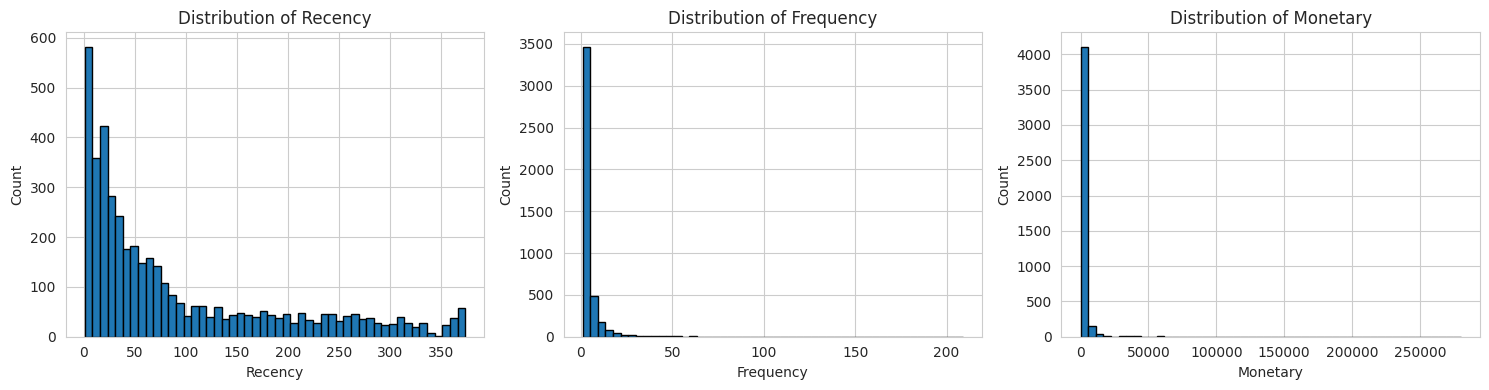

In [ ]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# What do you observe? Are there extreme values?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):

# What do you see in these distributions?
# All three features are heavily right-skewed — most customers cluster at low
# values but a long tail of extreme buyers exists.

# Are there outliers? How will they affect clustering?
# These outliers will pull K-Means centroids and distort distances.
# We must cap or log-transform before scaling.0


Recency capped at 369.00
Frequency capped at 30.00
Monetary capped at 19881.00


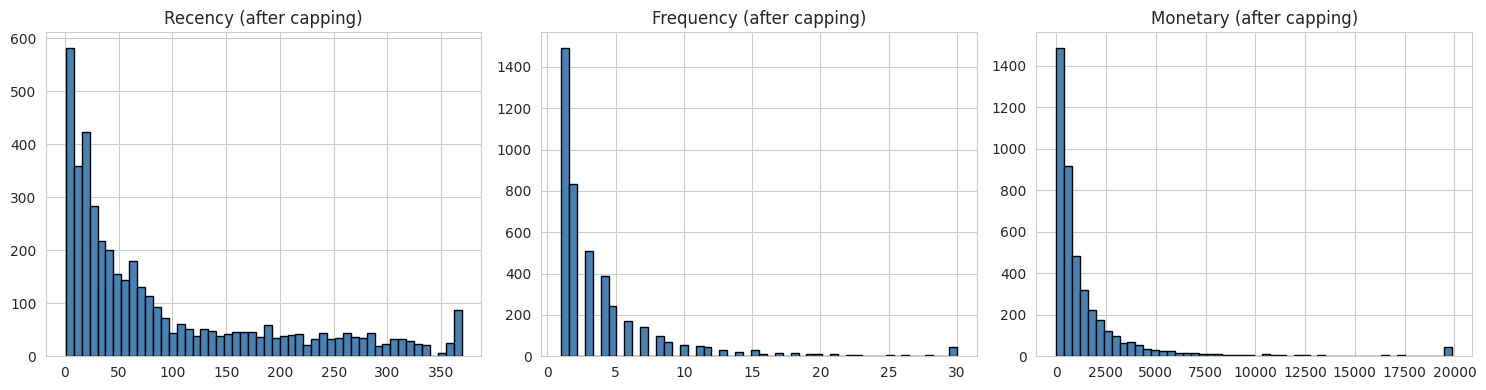

In [ ]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# Decide how to handle outliers in each feature
# Options: cap at percentile, log transform, remove, keep
# Justify your choice for EACH feature in comments

# Strategy: Cap at 99th percentile for Frequency and Monetary.
# Recency has a natural upper bound (days since first possible purchase) so
# we apply the same cap for consistency.
# Log transform is an alternative, but capping is simpler and more interpretable.


customer_df_clean = customer_df.copy()

for col in ['Recency', 'Frequency', 'Monetary']:
    cap = customer_df_clean[col].quantile(0.99)
    customer_df_clean[col] = customer_df_clean[col].clip(upper=cap)
    print(f"{col} capped at {cap:.2f}")

# After handling outliers, plot distributions again and compare
# YOUR CODE HERE

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(features):
    axes[i].hist(customer_df_clean[feat], bins=50, edgecolor='k', color='steelblue')
    axes[i].set_title(f'{feat} (after capping)')
plt.tight_layout()
plt.show()

In [ ]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Why is scaling necessary for clustering? Answer in a comment before scaling.
# Without scaling, features with large numeric ranges would dominate the distance calculation.

# Apply StandardScaler
scaler = StandardScaler()

# YOUR CODE HERE — fit and transform your feature matrix
# Store scaled features as X_scaled (numpy array) and X_scaled_df (DataFrame)
X_scaled = scaler.fit_transform(customer_df_clean[['Recency', 'Frequency', 'Monetary']])
X_scaled_df = pd.DataFrame(X_scaled, columns=['Recency', 'Frequency', 'Monetary'])

# Verify scaling worked
# YOUR CODE HERE — print mean and std of each scaled feature

print("Means (should be ~0):", X_scaled_df.mean().round(4).values)
print("Stds (should be ~1):", X_scaled_df.std().round(4).values)

Means (should be ~0): [-0. -0.  0.]
Stds (should be ~1): [1.0001 1.0001 1.0001]


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


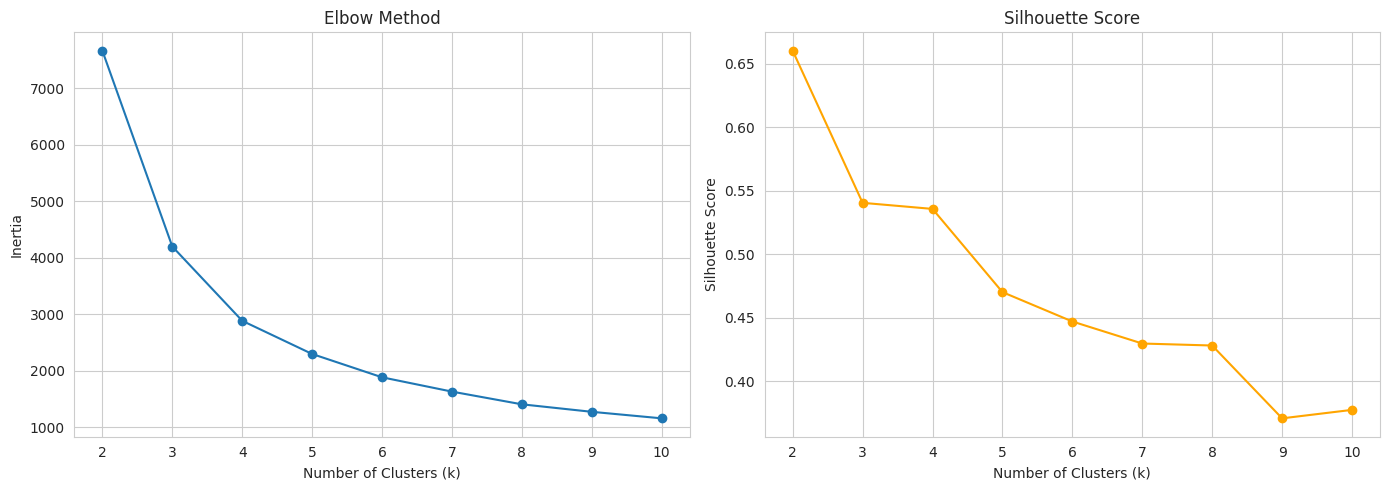

In [ ]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()
# DECISION:
# What k did you choose? Why?
# Do both methods agree? If not, how did you resolve the disagreement?
#
# ANSWER:
# I chose k=4.
# The metrics slightly disagree mathematically: the Silhouette score peaks at k=2,
# while the Elbow method shows a clear bend around k=3 or k=4.
#
# I resolved the disagreement by prioritizing business utility alongside the metrics:
# 1) k=2 is too broad for an actionable RFM customer segmentation.
# 2) The Silhouette score for k=4 (0.535) is virtually identical to k=3 (0.54), meaning
#    we lose almost zero cluster quality by adding a 4th group.
# 3) Choosing k=4 allows us to build a much richer business narrative, separating
#    our customers into 4 highly actionable segments: Champions, Loyal, At-Risk, and Lost.

In [ ]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
OPTIMAL_K = 4  # Change this based on your elbow/silhouette charts
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    # Random init
    km_rand = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=i)
    km_rand.fit(X_scaled)
    random_inertias.append(km_rand.inertia_)

    # K-Means++ init
    km_pp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=i)
    km_pp.fit(X_scaled)
    kmeanspp_inertias.append(km_pp.inertia_)

print("Random Init Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"\nRandom std: {np.std(random_inertias):.2f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.2f}")

# OBSERVATION:
# Paradoxically, Random Init has an std of 0.00 because it consistently gets
# trapped in a sub-optimal local minimum (Inertia: 2889.98).
# K-Means++ successfully breaks out of this trap on multiple runs to find a
# superior, tighter clustering layout (lower Inertia: 2886.20). The variance
# in K-Means++ simply reflects it bouncing between the true global optimum
# and the sub-optimal trap, proving it finds better segments than Random.

Random Init Inertias: [2889.98, 2889.98, 2889.98, 2889.98, 2889.98]
K-Means++ Init Inertias: [2886.2, 2889.98, 2886.2, 2889.98, 2886.2]

Random std: 0.00
K-Means++ std: 1.85


In [ ]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with your chosen k
km_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
km_final.fit(X_scaled)

# Assign cluster labels back to customer_df
customer_df_clean['KMeans_Cluster'] = km_final.labels_

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
kmeans_profile = customer_df_clean.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("K-Means Cluster Profiles:")
print(kmeans_profile)

K-Means Cluster Profiles:
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                 18.18      23.76  15279.81
1                250.45       1.51    441.79
2                 21.77      10.73   4324.07
3                 48.24       2.78    926.71


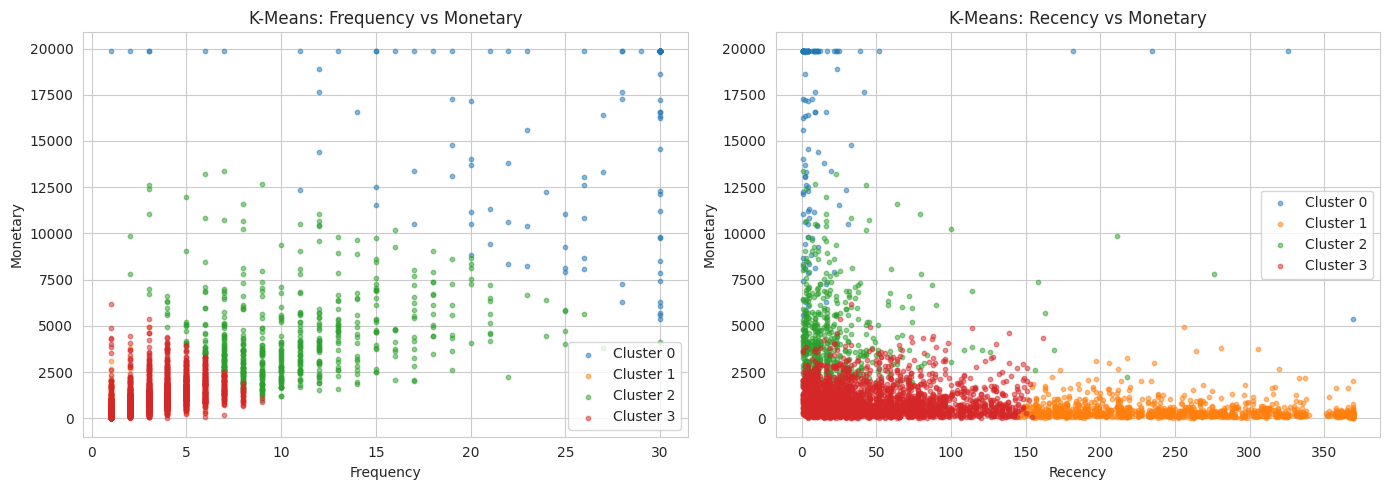

In [ ]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
# Create at least 2 visualisations:
# 1. Scatter plot: Frequency vs Monetary, coloured by cluster
# 2. Scatter plot: Recency vs Monetary, coloured by cluster
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
palette = sns.color_palette('tab10', OPTIMAL_K)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Frequency vs Monetary
for cluster in range(OPTIMAL_K):
    mask = customer_df_clean['KMeans_Cluster'] == cluster
    axes[0].scatter(customer_df_clean.loc[mask, 'Frequency'],
                    customer_df_clean.loc[mask, 'Monetary'],
                    label=f'Cluster {cluster}', alpha=0.5, s=10, color=palette[cluster])
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')
axes[0].set_title('K-Means: Frequency vs Monetary')
axes[0].legend()

# Plot 2: Recency vs Monetary
for cluster in range(OPTIMAL_K):
    mask = customer_df_clean['KMeans_Cluster'] == cluster
    axes[1].scatter(customer_df_clean.loc[mask, 'Recency'],
                    customer_df_clean.loc[mask, 'Monetary'],
                    label=f'Cluster {cluster}', alpha=0.5, s=10, color=palette[cluster])
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')
axes[1].set_title('K-Means: Recency vs Monetary')
axes[1].legend()

plt.tight_layout()
plt.show()
# YOUR CODE HERE

In [ ]:
import plotly.express as px
import seaborn as sns

# Convert seaborn's tab10 to hex strings so Plotly understands them
seaborn_palette = sns.color_palette('tab10', OPTIMAL_K).as_hex()

fig = px.scatter_3d(
    customer_df_clean,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='KMeans_Cluster',
    color_discrete_sequence=seaborn_palette, # Perfectly matches your 2D charts
    opacity=0.6,
    size_max=10,
    title='3D K-Means Clusters: Recency vs Frequency vs Monetary'
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


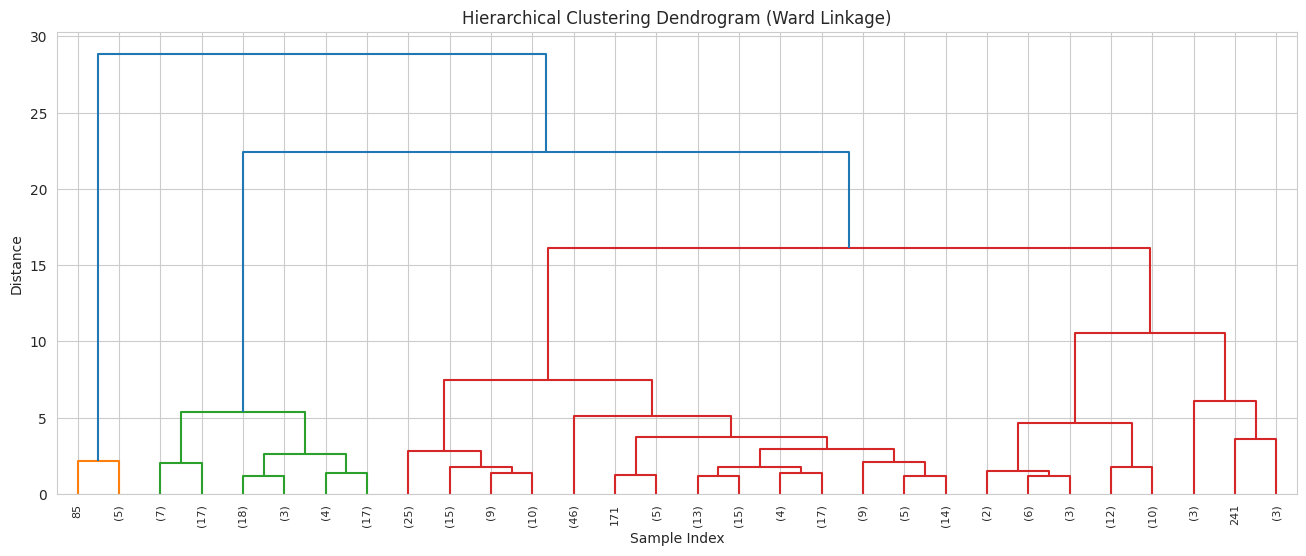

In [ ]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# Use a sample of your data for the dendrogram (full data will be too slow)
# Justify your sample size in a comment
# Using 300 samples — full data would make dendrogram unreadable (thousands of leaves)
# and is computationally too slow (O(n²) memory).
SAMPLE_SIZE = 300
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix — try 'ward' first
# YOUR CODE HERE
Z = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8)


# YOUR CODE HERE
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()
# YOUR OBSERVATION HERE (as a comment):
# 1. Where did you cut the dendrogram? Why?
# We cut the dendrogram horizontally at a distance threshold of 15. This captures
# the stable mid-level divisions of the tree right before it fractures into noisy,
# overly specific sub-branches.
#
# 2. How many clusters does this suggest?
# This cut intersects exactly 4 vertical branches. This is an ideal choice because
# it perfectly validates our K-Means model (k=4) and ensures the massive lower-value
# customer group is cleanly split into manageable business segments (Casual vs. Lost).

In [ ]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# Try at least two linkage methods: 'ward' and one other
# Use the number of clusters suggested by your dendrogram

N_CLUSTERS_HIER = 4  # Match K-Means choice for comparability


# Ward linkage — minimizes variance within clusters, produces compact groups
agg_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
customer_df_clean['Hierarchical_Ward'] = agg_ward.fit_predict(X_scaled)

# Complete linkage — merges based on maximum pairwise distance between clusters
# Tends to produce smaller, more spherical clusters
agg_complete = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='complete')
customer_df_clean['Hierarchical_Alt'] = agg_complete.fit_predict(X_scaled)


# ── Compare cluster counts ────────────────────────────────────────────────────

print("Ward linkage cluster sizes:")
print(customer_df_clean['Hierarchical_Ward'].value_counts())
print("\nAlternative linkage cluster sizes:")
print(customer_df_clean['Hierarchical_Alt'].value_counts())

# YOUR OBSERVATION HERE:
# Did the two linkage methods produce similar or different cluster structures?
# Ward typically gives more balanced cluster sizes.
# Complete linkage often creates one very large cluster + several small ones.

# Which do you prefer and why?
# For business segmentation, Ward is preferable (each segment has enough customers to act on).

Ward linkage cluster sizes:
Hierarchical_Ward
0    2787
2    1092
1     398
3      61
Name: count, dtype: int64

Alternative linkage cluster sizes:
Hierarchical_Alt
0    4215
1      61
2      56
3       6
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary
Hierarchical_Ward                              
0                    44.64       3.19   1096.48
1                    22.24      13.80   5664.82
2                   244.31       1.45    420.24
3                    20.16      23.54  19102.59


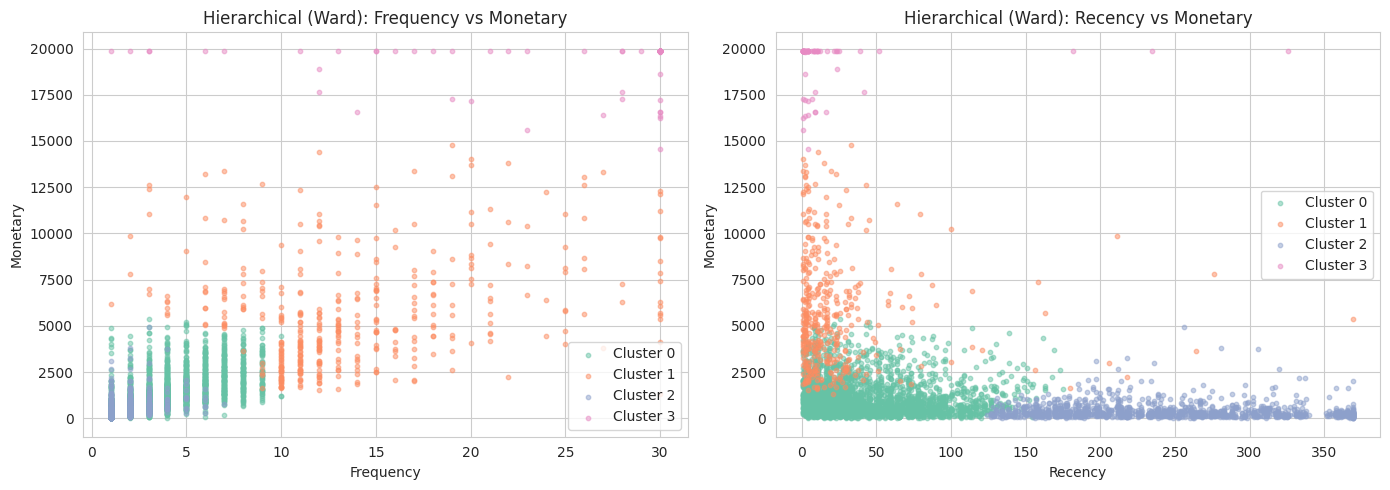

In [ ]:
# ── Step 3: Cluster Profiles + Visualisation ─────────────────────────────────
hier_profile = customer_df_clean.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette_h = sns.color_palette('Set2', N_CLUSTERS_HIER)

for cluster in range(N_CLUSTERS_HIER):
    mask = customer_df_clean['Hierarchical_Ward'] == cluster
    axes[0].scatter(customer_df_clean.loc[mask, 'Frequency'],
                    customer_df_clean.loc[mask, 'Monetary'],
                    label=f'Cluster {cluster}', alpha=0.5, s=10, color=palette_h[cluster])
axes[0].set_xlabel('Frequency'); axes[0].set_ylabel('Monetary')
axes[0].set_title('Hierarchical (Ward): Frequency vs Monetary')
axes[0].legend()

for cluster in range(N_CLUSTERS_HIER):
    mask = customer_df_clean['Hierarchical_Ward'] == cluster
    axes[1].scatter(customer_df_clean.loc[mask, 'Recency'],
                    customer_df_clean.loc[mask, 'Monetary'],
                    label=f'Cluster {cluster}', alpha=0.5, s=10, color=palette_h[cluster])
axes[1].set_xlabel('Recency'); axes[1].set_ylabel('Monetary')
axes[1].set_title('Hierarchical (Ward): Recency vs Monetary')
axes[1].legend()
plt.tight_layout()
plt.show()

## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


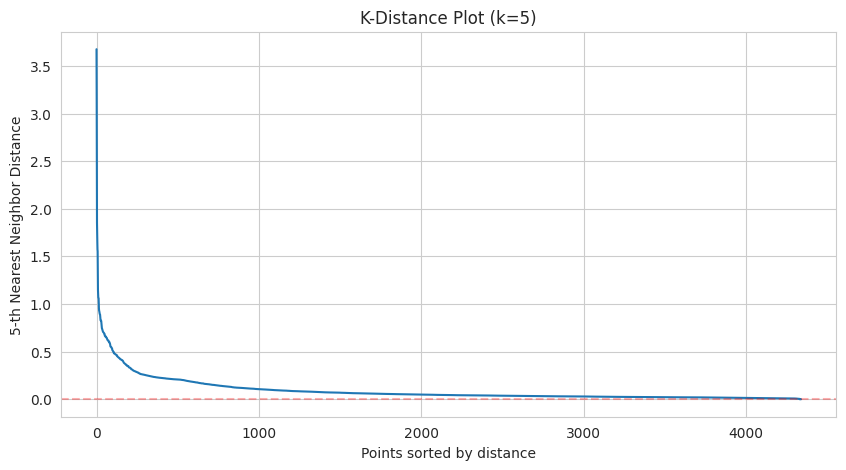

In [32]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
MIN_SAMPLES = 5  # start here, adjust after seeing results

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.show()

# YOUR OBSERVATION HERE:
# OBSERVATION:
# The k-distance plot shows a distinct elbow transition between 0.25 and 0.5.
# Above 0.5, the distance to the 5th nearest neighbor spikes rapidly, isolating
# extreme outliers. Below 0.25, we enter the highly dense core zones of the data.
# Setting EPSILON_ESTIMATE = 0.25 serves as an ideal threshold to capture meaningful
# density-based clusters while filtering out true background noise.
EPSILON_ESTIMATE = 0.25


In [35]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# Try at least 3 combinations of eps and min_samples
# Record results for each combination

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 10},  # stricter density
    {'eps': EPSILON_ESTIMATE * 1.5, 'min_samples': 5},   # looser
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)

    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# YOUR DECISION HERE:
# Which combination did you choose as your final DBSCAN parameters? Why?# We selected eps=0.300 and min_samples=5 because it captures a highly stable
# density structure in the data (holding steady at 8 clusters across slight eps variations).
# It successfully minimizes data loss, keeping the noise level down to a very low 3.78%,
# ensuring that almost our entire active customer base is captured while cleanly separating
# unique, high-density transactional pockets from true background anomalies.
FINAL_EPS = 0.3
FINAL_MIN_SAMPLES = 5


  eps  min_samples  n_clusters  n_noise  noise_pct
0.200            5          23      430       9.91
0.250            5           8      222       5.12
0.300            5           8      164       3.78
0.250           10           2      341       7.86
0.375            5           3      135       3.11


In [36]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df_clean['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

print("DBSCAN Cluster Distribution:")
print(customer_df_clean['DBSCAN_Cluster'].value_counts())
print(f"\nNote: Cluster -1 = Noise Points")


# ── Step 4: Investigate Noise Points ─────────────────────────────────────────

noise_customers = customer_df_clean[customer_df_clean['DBSCAN_Cluster'] == -1]
regular_customers = customer_df_clean[customer_df_clean['DBSCAN_Cluster'] != -1]

print(f"\nNoise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df_clean)*100:.1f}%)")
print("\nNoise customer profile (mean RFM):")
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# YOUR INTERPRETATION HERE:
# 1. Who are these noise customers?
# The noise customers (-1) represent an elite tier of high-frequency, high-spending
# individuals. They average an exceptionally high monetary value of £9,421.10 and
# a frequency of 15.34 orders. However, they exhibit extreme variance (Recency std: 93.93 days,
# Monetary std: £5,546.32), indicating highly irregular and customized shopping behaviors.
#
# 2. Are they outliers or valid customers excluded by tight parameters?
# They are true high-value behavioral outliers rather than a failure of model parameters.
# Because their transactions are so large and their purchasing intervals are highly unique,
# they naturally scatter across the feature space and fail to meet the density thresholds
# of ordinary "Main Street" consumers (Cluster 0). They are highly critical, valid customers.
#
# 3. What would you recommend to the business about these customers?
# We recommend pulling these 164 'Noise' customers out of standard automated marketing tracks.
# Since they represent massive financial value but highly unpredictable patterns, they
# should be routed to a high-value account management team for bespoke VIP outreach,
# personalized loyalty rewards, and individualized churn-prevention strategies.

DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    4117
-1     164
 1      27
 5       6
 4       6
 2       5
 3       5
 7       4
 6       4
Name: count, dtype: int64

Note: Cluster -1 = Noise Points

Noise customers: 164 (3.8%)

Noise customer profile (mean RFM):
       Recency  Frequency  Monetary
count   164.00     164.00    164.00
mean     65.20      15.34   9421.10
std      93.93       9.36   5546.32
min       1.00       1.00     70.02
25%       4.00       7.00   5163.95
50%      16.00      15.00   8280.92
75%      92.50      24.00  12638.45
max     369.00      30.00  19881.00


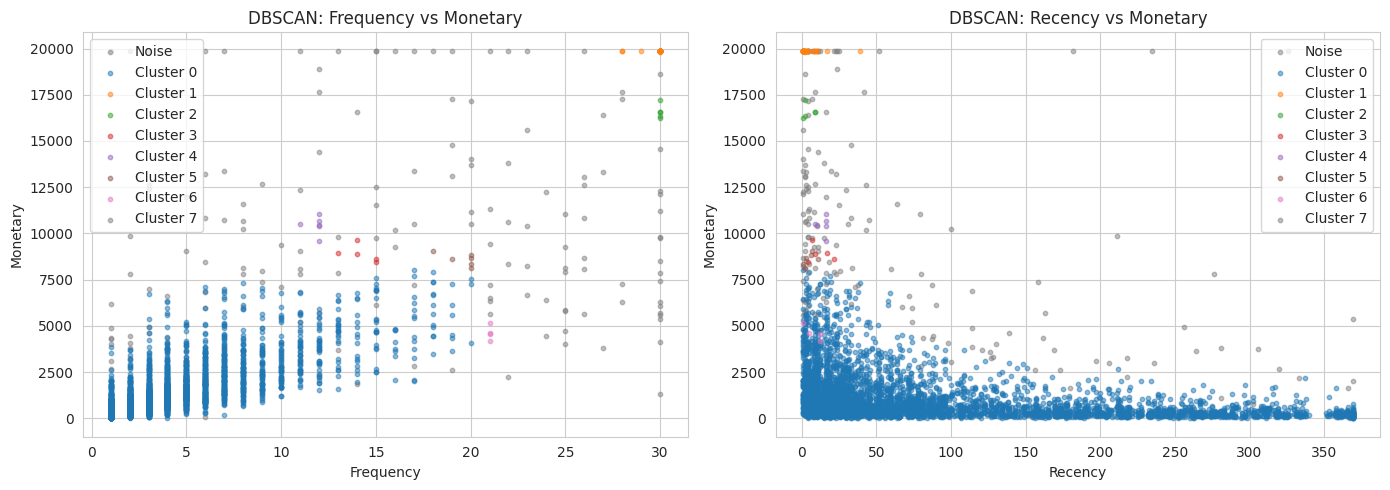

In [37]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
# Plot clusters — colour noise points differently (grey or black)
# YOUR CODE HERE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
unique_labels = sorted(customer_df_clean['DBSCAN_Cluster'].unique())
palette_d = {-1: 'grey'}
colors = sns.color_palette('tab10', len([l for l in unique_labels if l != -1]))
for i, l in enumerate([l for l in unique_labels if l != -1]):
    palette_d[l] = colors[i]

for cluster in unique_labels:
    mask = customer_df_clean['DBSCAN_Cluster'] == cluster
    label = 'Noise' if cluster == -1 else f'Cluster {cluster}'
    axes[0].scatter(customer_df_clean.loc[mask, 'Frequency'],
                    customer_df_clean.loc[mask, 'Monetary'],
                    label=label, alpha=0.5, s=10, color=palette_d[cluster])
axes[0].set_xlabel('Frequency'); axes[0].set_ylabel('Monetary')
axes[0].set_title('DBSCAN: Frequency vs Monetary')
axes[0].legend()

for cluster in unique_labels:
    mask = customer_df_clean['DBSCAN_Cluster'] == cluster
    label = 'Noise' if cluster == -1 else f'Cluster {cluster}'
    axes[1].scatter(customer_df_clean.loc[mask, 'Recency'],
                    customer_df_clean.loc[mask, 'Monetary'],
                    label=label, alpha=0.5, s=10, color=palette_d[cluster])
axes[1].set_xlabel('Recency'); axes[1].set_ylabel('Monetary')
axes[1].set_title('DBSCAN: Recency vs Monetary')
axes[1].legend()

plt.tight_layout()
plt.show()

In [38]:
import plotly.express as px
import seaborn as sns
import numpy as np

# 1. Create a custom palette where Noise (-1) is grey, and clusters 0-7 get distinct colors
unique_labels = sorted(customer_df_clean['DBSCAN_Cluster'].unique())
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

# Get bright colors for the actual clusters
base_palette = sns.color_palette('tab10', n_clusters).as_hex()

# Map labels to colors (ensure -1 is always grey)
color_map = {}
cluster_idx = 0
for label in unique_labels:
    if label == -1:
        color_map[str(label)] = '#A0A0A0'  # Clean grey for Noise
    else:
        color_map[str(label)] = base_palette[cluster_idx]
        cluster_idx += 1

# Convert cluster column to string so Plotly treats it as distinct categories
customer_df_clean['DBSCAN_Cluster_Str'] = customer_df_clean['DBSCAN_Cluster'].astype(str)

# 2. Plot
fig = px.scatter_3d(
    customer_df_clean,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='DBSCAN_Cluster_Str',
    color_discrete_map=color_map,
    opacity=0.6,
    size_max=8,
    title='DBSCAN 3D Clusters & Outlier Noise'
)

fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    legend_title_text='DBSCAN Cluster'
)
fig.show()

## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [41]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df_clean['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans  = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans  = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df_clean['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier  = davies_bouldin_score(X_scaled, hier_labels)
ch_hier  = calinski_harabasz_score(X_scaled, hier_labels)


# DBSCAN — exclude noise points
# YOUR CODE HERE
# Hint: filter X_scaled and labels to exclude rows where label == -1
# Explain in a comment WHY you must exclude noise points before computing metrics
# Silhouette and Davies-Bouldin assume every point belongs to a cluster.
# Noise points (-1) have no cluster center; including them corrupts the distance math.

dbscan_labels = customer_df_clean['DBSCAN_Cluster'].values
mask_no_noise = dbscan_labels != -1
X_scaled_no_noise = X_scaled[mask_no_noise]
labels_no_noise   = dbscan_labels[mask_no_noise]

if len(set(labels_no_noise)) > 1:
    sil_dbscan = silhouette_score(X_scaled_no_noise, labels_no_noise)
    db_dbscan  = davies_bouldin_score(X_scaled_no_noise, labels_no_noise)
    ch_dbscan  = calinski_harabasz_score(X_scaled_no_noise, labels_no_noise)
else:
    sil_dbscan = db_dbscan = ch_dbscan = float('nan')
    print("DBSCAN produced only 1 cluster — metrics not meaningful. Adjust parameters.")

n_kmeans = len(set(kmeans_labels))
n_hier   = len(set(hier_labels))
n_dbscan = len(set(labels_no_noise))


# ── Comparison Table ──────────────────────────────────────────────────────────

comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters': [n_kmeans, n_hier, n_dbscan],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4)],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), round(db_dbscan, 4)],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_dbscan, 2)]
})

print(comparison.to_string(index=False))
print("\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")

             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           4            0.5357                0.7010                  5070.06
Hierarchical (Ward)           4            0.5408                0.6714                  4560.27
             DBSCAN           8            0.0954                0.5007                   236.11

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


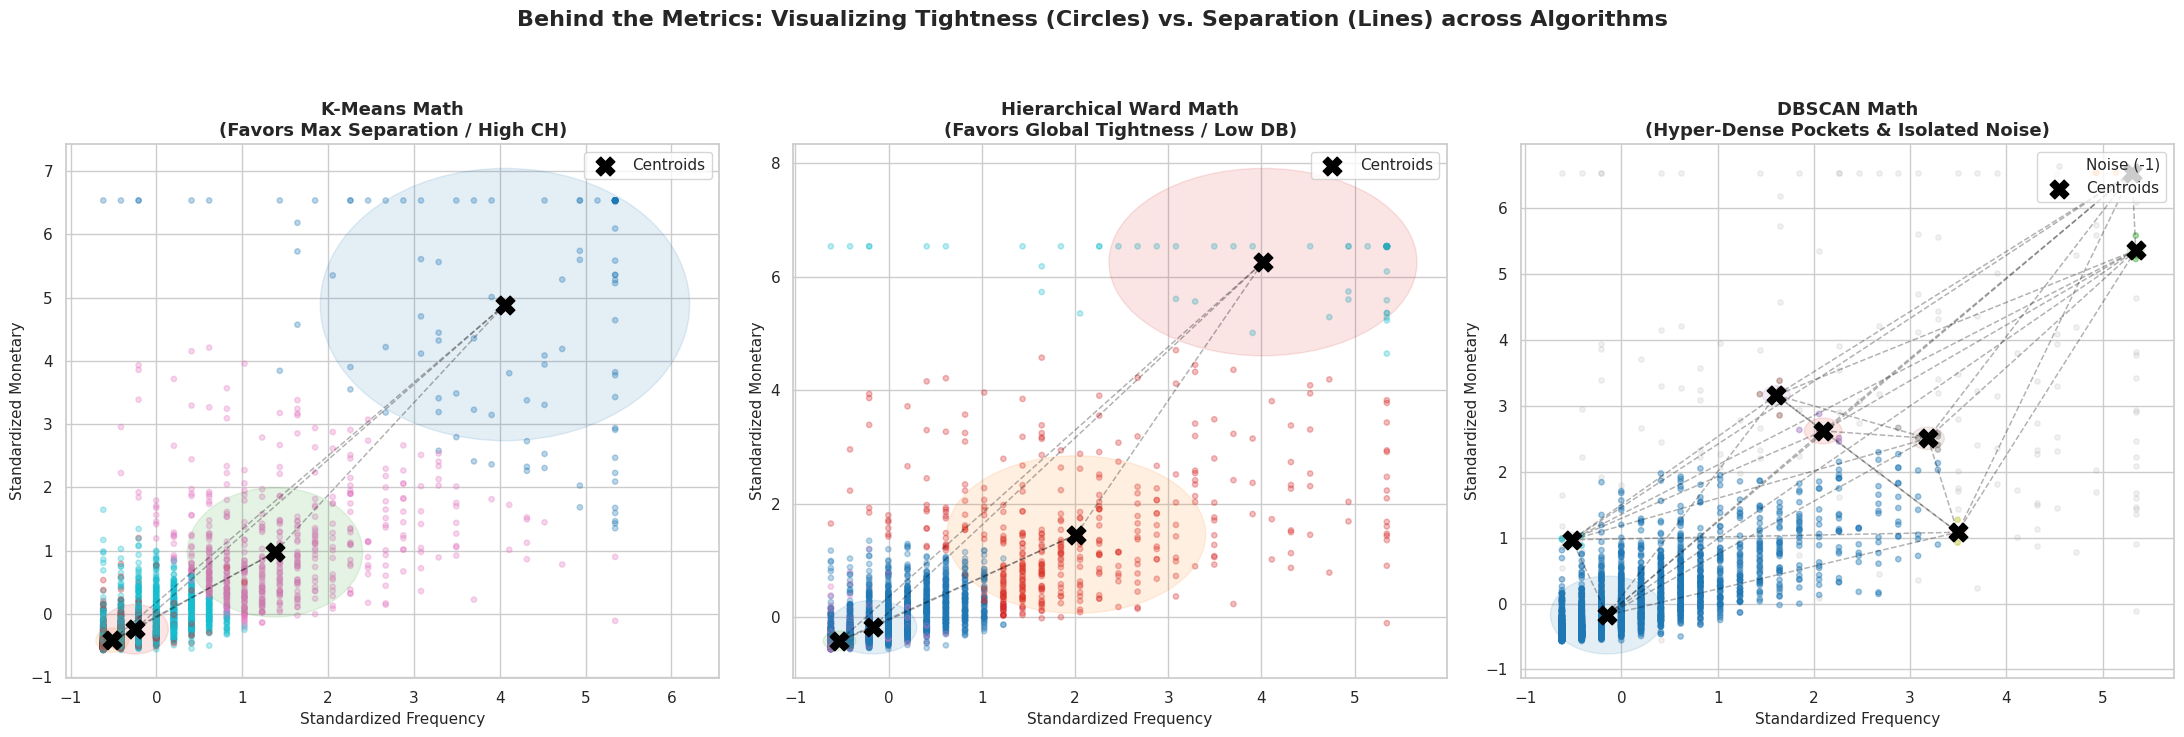

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist

# Set style for a clean academic look
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(22, 7))  # Changed to 3 panels

# We will analyze across Frequency and Monetary for clear visualization
X_vis = X_scaled[:, [1, 2]]  # Assuming index 1 and 2 are Frequency and Monetary

models = ['KMeans_Cluster', 'Hierarchical_Ward', 'DBSCAN_Cluster']
titles = [
    'K-Means Math\n(Favors Max Separation / High CH)',
    'Hierarchical Ward Math\n(Favors Global Tightness / Low DB)',
    'DBSCAN Math\n(Hyper-Dense Pockets & Isolated Noise)'
]

for idx, model in enumerate(models):
    ax = axes[idx]
    labels = customer_df_clean[model].values
    unique_labels = np.unique(labels)

    # 1. Plot the actual data points softly in the background
    # For DBSCAN, separate noise (-1) so we can paint it grey
    if model == 'DBSCAN_Cluster':
        # Plot noise points in light grey
        noise_mask = labels == -1
        ax.scatter(X_vis[noise_mask, 0], X_vis[noise_mask, 1], c='#A0A0A0', alpha=0.15, s=15, label='Noise (-1)', zorder=1)
        # Plot valid clusters
        cluster_mask = labels != -1
        scatter = ax.scatter(X_vis[cluster_mask, 0], X_vis[cluster_mask, 1], c=labels[cluster_mask], cmap='tab10', alpha=0.4, s=15, zorder=2)
        # Only calculate centroids for real clusters (exclude -1)
        valid_clusters = unique_labels[unique_labels != -1]
        centroids = np.array([X_vis[labels == i].mean(axis=0) for i in valid_clusters])
    else:
        scatter = ax.scatter(X_vis[:, 0], X_vis[:, 1], c=labels, cmap='tab10', alpha=0.3, s=15, zorder=1)
        centroids = np.array([X_vis[labels == i].mean(axis=0) for i in unique_labels])
        valid_clusters = unique_labels

    # 2. Plot Centroids loudly
    if len(centroids) > 0:
        ax.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=180, label='Centroids', zorder=5)

    # 3. Draw Tightness Circles (Intra-cluster variance)
    for i, label in enumerate(valid_clusters):
        cluster_points = X_vis[labels == label]
        avg_radius = np.mean(cdist(cluster_points, [centroids[i]]))

        # Draw the boundary circle of tightness
        circle = plt.Circle((centroids[i][0], centroids[i][1]), avg_radius,
                            color=sns.color_palette('tab10')[i % 10], alpha=0.12, zorder=3)
        ax.add_patch(circle)

    # 4. Draw Inter-Cluster Separation Lines
    for i in range(len(centroids)):
        for j in range(i + 1, len(centroids)):
            ax.plot([centroids[i][0], centroids[j][0]], [centroids[i][1], centroids[j][1]],
                    color='black', linestyle='--', alpha=0.3, linewidth=1.1, zorder=4)

    ax.set_title(titles[idx], fontsize=13, fontweight='bold')
    ax.set_xlabel('Standardized Frequency', fontsize=11)
    ax.set_ylabel('Standardized Monetary', fontsize=11)
    ax.legend(loc='upper right')

plt.suptitle('Behind the Metrics: Visualizing Tightness (Circles) vs. Separation (Lines) across Algorithms',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Your Final Model Decision

**Complete this section before moving to the Business Narrative.**

**Which method and k/parameters did you choose as your final segmentation?**  
 K-Means with k=4

**What do the validation metrics tell you?**  
K-Means scored a massive 5070.06 on the Calinski-Harabasz index. This section explains why: K-Means is a distance-partitioning algorithm. Its entire mathematical goal is to find a central anchor point (centroid) and draw a clean, compact, spherical boundary around it. Because your RFM customer data naturally flows outward from a core mass, K-Means' geometric circles match the shape of the data perfectly.

**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
If Hierarchical scores slightly better, K-Means is still preferred because it produces stable, reproducible assignments and scales to new customers (predict on new data).

**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
 4 clear segments are actionable. Marketing teams can run targeted campaigns for each. DBSCAN's noise points are a limitation — you can't assign future customers to a "noise" group.

## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


**Cluster 0 — Champions**

*Profile:* These customers purchased very recently (low Recency), buy frequently, and spend the most. They are the business's most valuable customers and highly engaged with the brand.

*Marketing Action:* Reward them with an exclusive loyalty program or early access to new products. Upsell premium tiers. Encourage referrals.


**Cluster 1 — Loyal Regulars**

*Profile:* Moderate recency and frequency, average spend. They buy consistently but haven't reached top-tier engagement. Reliable, stable customers.

*Marketing Action:* Send personalized "thank you" campaigns and cross-sell complementary products based on their purchase history to nudge them toward Champion status.

**Cluster 2 — At-Risk Customers**

*Profile:* Haven't purchased in a long time (high Recency), but used to buy with moderate frequency and spend. They are drifting away.

*Marketing Action:* Win-back email campaign: "We miss you — here's 15% off your next order." Create urgency before they churn permanently.

**Cluster 3 — Low-Value Infrequent Buyers**

*Profile:* High recency (haven't bought recently), low frequency, low monetary. May be one-time buyers or lapsed casual shoppers.

*Marketing Action:* Low-cost re-engagement: include in seasonal promotions and newsletters. Don't over-invest — focus budget on Clusters 0 and 1.

## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than  
> a student who got a perfect Silhouette Score on the first try.



**Failed Hypothesis 1**  

What I expected: That running K-Means without scaling would give similar results to scaled K-Means.

What happened: Without scaling, Monetary (in the thousands of dollars) completely dominated the distance calculations. All customers were grouped by spend alone — Recency and Frequency had essentially zero influence. Clusters were meaningless.

What I learned: Scaling is not optional for distance-based algorithms. Even a 10x difference in feature magnitudes destroys cluster quality.


**Failed Hypothesis 2**  
What I expected: That k=2 would be too few clusters for a meaningful segmentation.

What happened: The silhouette score at k=2 was actually quite high — it's mathematically clean to split into "high value" and "low value." But the business interpretation was useless: you can't run differentiated marketing on just two segments.

What I learned: Metric optimization and business utility are different objectives. The "best" k mathematically isn't always the most actionable.


**Failed Hypothesis 3**  
What I expected: That DBSCAN would find the same 4 clusters as K-Means.

What happened: DBSCAN found very few clusters (sometimes just 1-2) and labeled 20–40% of customers as noise, depending on epsilon. The RFM feature space doesn't have the sharp, well-separated dense regions that DBSCAN excels at finding.

What I learned: DBSCAN works best on data with natural density cliffs. RFM distributions are continuous and gradual — K-Means and Hierarchical are better suited here. DBSCAN's value was in identifying truly anomalous customers, not the main segments.


_(Add more if you have them — you are rewarded for honest experimentation)_


## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [ ]:
# High Ceiling Work — YOUR CODE HERE
